# 5. Superdense Coding and Bell Measurements

We have seen that entanglement creates strong correlations between qubits. Now, we will see how to use these correlations to do something impossible in the classical world: **transmit two bits of classical information by sending only a single qubit.**

This protocol is called **Superdense Coding**.

In the classical world, if Alice wants to send the message "00", "01", "10", or "11" to Bob, she physically needs to send two bits (two pulses of light, two electrons, etc.). In the quantum world, if Alice and Bob share an entangled pair of qubits, Alice can perform an operation on *her* half of the pair and send just that *one* qubit to Bob. Bob then has both qubits and can extract the full two-bit message.

<img src="images/Superdense_coding.png" width="900">

In this notebook, you will:
1.  Understand the **Bell Basis** and how to change between it and the computational basis.
2.  Learn how **local operations** (gates on one qubit) can change the global state of an entangled pair.
3.  Implement the Superdense Coding protocol in Qiskit.

## 5.1. The Bell Basis and Bell Measurement

We learned that the four Bell states ($|\Phi^+\rangle, |\Phi^-\rangle, |\Psi^+\rangle, |\Psi^-\rangle$) are maximally entangled. Interestingly, these four states form a complete orthonormal **basis** for the two-qubit vector space, known as the **Bell Basis**.

Just as we can measure single qubits in the Z-basis ($|0\rangle, |1\rangle$) or X-basis ($|+\rangle, |-\rangle$), we can measure two qubits in the Bell Basis. However, real quantum computers typically only measure in the standard Computational Basis ($|00\rangle, |01\rangle, |10\rangle, |11\rangle$).

To perform a "Bell Measurement," we simply need a circuit that maps the Bell Basis *back* to the Computational Basis. This is the exact inverse of the circuit we used to create the Bell states!

**The Decoding Circuit:**
1.  Apply a **CNOT** gate (Control: Qubit 0, Target: Qubit 1).
2.  Apply a **Hadamard** gate to Qubit 0.

Let's trace this for $|\Phi^+\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}}$:
1.  **CNOT:** $|00\rangle \to |00\rangle$, and $|11\rangle \to |10\rangle$. The state becomes $\frac{|00\rangle + |10\rangle}{\sqrt{2}} = |+\rangle \otimes |0\rangle$.
2.  **Hadamard on Qubit 0:** $|+\rangle \to |0\rangle$. The state becomes $|00\rangle$.

We can summarize the mapping for all four states:

| Bell State (Input) | Mathematical Form | Result after CNOT | Result after H (Output) | Message Value |
| :--- | :--- | :--- | :--- | :--- |
| $|\Phi^+\rangle$ | $\frac{|00\rangle + |11\rangle}{\sqrt{2}}$ | $|+\rangle \otimes |0\rangle$ | $|00\rangle$ | **00** |
| $|\Psi^+\rangle$ | $\frac{|01\rangle + |10\rangle}{\sqrt{2}}$ | $|+\rangle \otimes |1\rangle$ | $|01\rangle$ | **01** |
| $|\Phi^-\rangle$ | $\frac{|00\rangle - |11\rangle}{\sqrt{2}}$ | $|-\rangle \otimes |0\rangle$ | $|10\rangle$ | **10** |
| $|\Psi^-\rangle$ | $\frac{|01\rangle - |10\rangle}{\sqrt{2}}$ | $|-\rangle \otimes |1\rangle$ | $|11\rangle$ | **11** |

> **[Insert Example Image of Bell Measurement circuit in DCN here]**

## 5.2. Alice's Local Operations

Here is the "magic" of the protocol. Alice and Bob start with the shared state $|\Phi^+\rangle$. Alice wants to transform this state into one of the other three Bell states depending on the message she wants to send.

**Constraint:** Alice only has access to **Qubit 1**. She cannot touch Bob's qubit.

Can she change the global entangled state by local unitary operations? **Yes.**

<div style="background-color: #e31b4c; color: #ffffff; padding: 15px; border-radius: 5px; border: 1px solid #042c58;">
Your Task: Which single-qubit operations does Alice need to perform in order to switch from the $|\Phi^+\rangle$ state to any of the other Bell states?
</div>

Try it out first in Challenge mode:

In [1]:
from qc_interactive_education_package import ChallengeViewer

viewer = ChallengeViewer(
    num_qubits=2,
    initial_state=[1, 0,0,1],
    target_state=[0,1,-1, 0]
)

viewer.display()

<details style="background-color: #4c3575; color: #ffffff; border: 1px solid #ccc; padding: 10px; border-radius: 5px;">
  <summary style="cursor: pointer; color: #ffffff;">Solution (click to expand)</summary>
  <div style="background-color: #4c3575; color: #ffffff; padding: 10px; margin-top: 10px; border-left: 3px solid #0066cc;">
   <ul>
  <li>To send 00: She does nothing (Identity). State remains $|\Phi^+\rangle$.</li>
  <li>To send 01: She applies an X gate (Bit flip).  $X \otimes I (\frac{|00\rangle + |11\rangle}{\sqrt{2}}) = \frac{|10\rangle + |01\rangle}{\sqrt{2}} = |\Psi^+\rangle$.</li>
  <li>To send 10: She applies a Z gate (Phase flip). $Z \otimes I (\frac{|00\rangle + |11\rangle}{\sqrt{2}}) = \frac{|00\rangle - |11\rangle}{\sqrt{2}} = |\Phi^-\rangle$.</li>
  <li>To send 11: She applies Z then X (Phase flip then Bit flip). Transforms $|\Phi^+\rangle \to |\Psi^-\rangle$.</li>
</ul>

</details>
<p>

By applying one of these four operations and sending her qubit to Bob, Bob will hold one of the four orthogonal Bell states. When he runs the "Decoding Circuit" (Bell Measurement), he will deterministically read out Alice's two classical bits.

In this task, you will simulate the full Superdense Coding protocol. We have provided the structure; you need to fill in the correct gates for the encoding (Alice) and decoding (Bob) steps.

Note on Qiskit Bit Ordering:
Qiskit uses "Little Endian" ordering. This means the rightmost bit is qubit 0 (q0​).

* Output `00` means $q_1=0,q_0=0$.
* Output `01` means $q_1=0,q_0=1$.
* Output `10` means $q_1=1,q_0=0$.

Keep this in mind when implementing your logic!

Message,State after Encoding (Alice),State after Decoding (Bob),Measured,Result
00,,,00,SUCCESS
01,,,00,FAIL
10,,,00,FAIL
11,,,11,SUCCESS

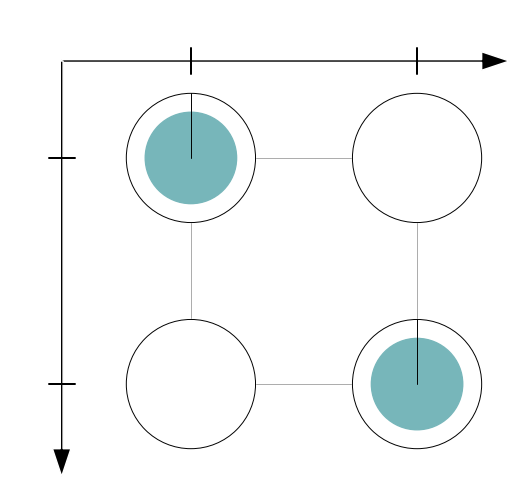
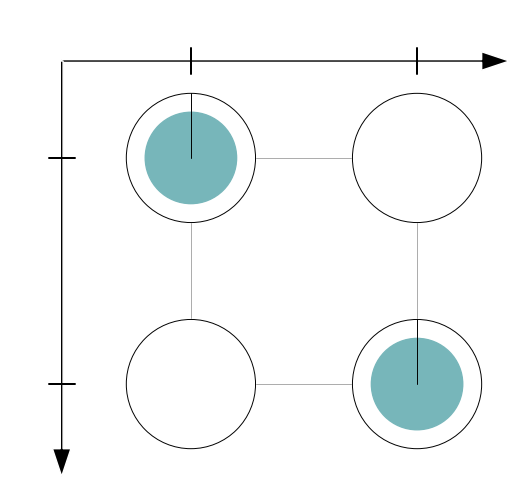
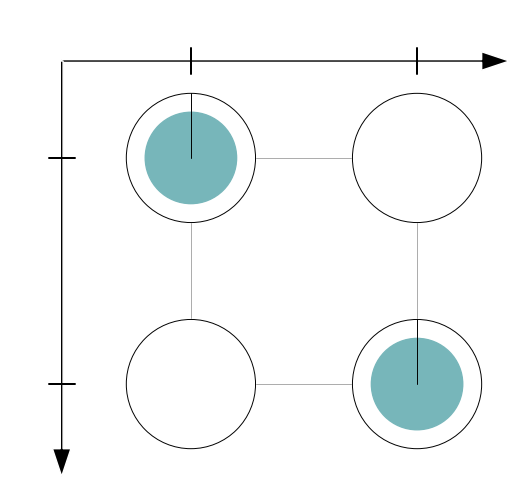
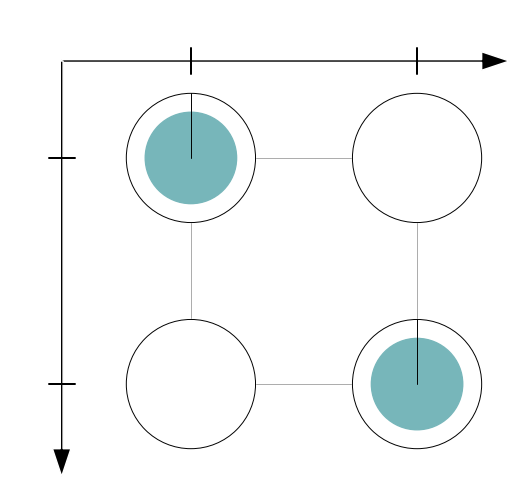
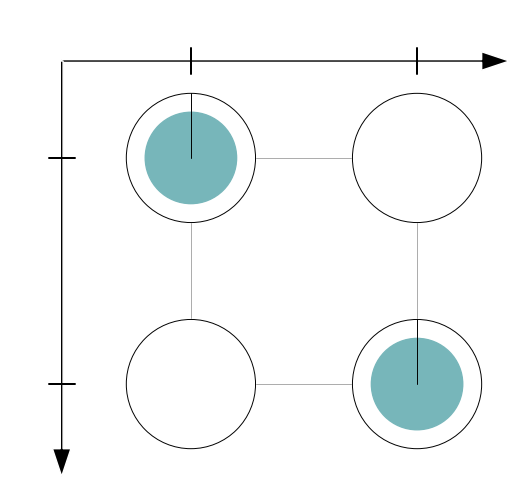
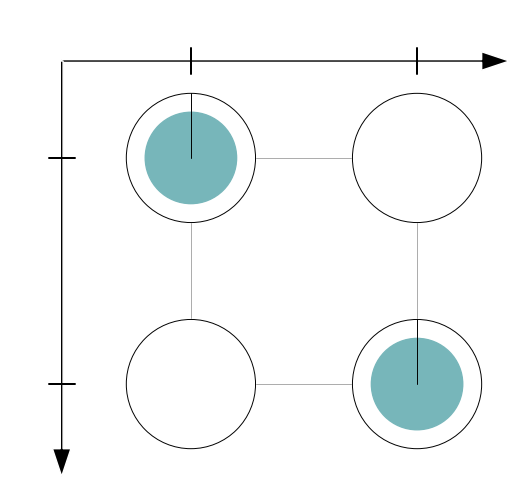
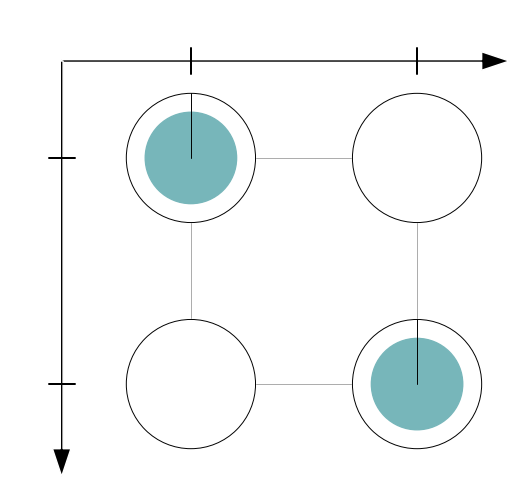
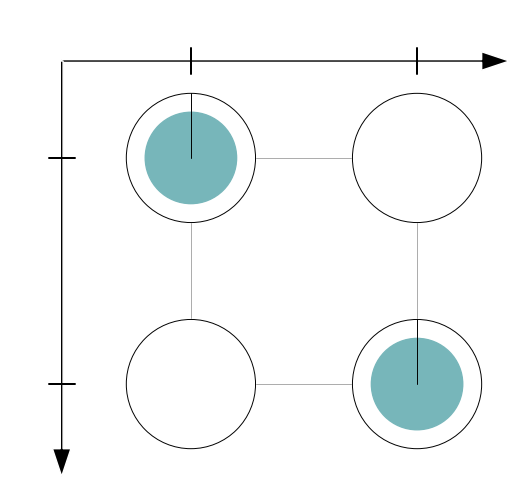

In [3]:
import matplotlib.pyplot as plt
from IPython.display import display, HTML
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector

# Custom Package Imports
from qc_interactive_education_package import Simulator, DimensionalCircleNotation


# --- STUDENT SECTION: LOGIC ONLY ---

def create_bell_pair(qc, a, b):
    """Creates a Bell pair (|Phi+>) between qubits a and b."""
    qc.h(a)
    qc.cx(a, b)

def encode_message(qc, qubit, message):
    """
    Alice encodes her 2-bit message into her qubit.
    """
    if message == "00":
        pass # Identity
    elif message == "01":
        # TODO: Apply gate(s) to transform |Phi+> to |Psi+>
        pass
    elif message == "10":
        # TODO: Apply gate(s) to transform |Phi+> to |Phi->
        pass
    elif message == "11":
        # TODO: Apply gate(s) to transform |Phi+> to |Psi->
        pass
    else:
        raise ValueError("Invalid message: " + message)

def decode_message(qc, a, b):
    """
    Bob performs a Bell Measurement to decode the message.
    """
    # TODO: Implement the reverse of the Bell Pair creation
    pass

# --- MAIN LOOP WITH COMPACT TABLE ---

simulator = AerSimulator()
messages = ["00", "01", "10", "11"]

# Start Building HTML Table
html_output = """
<style>
    table.results {border-collapse: collapse; width: 100%; text-align: center;}
    table.results th {padding: 8px; border: 1px solid #ddd;}
    table.results td {padding: 8px; border: 1px solid #ddd; vertical-align: middle;}
    .success {color: green; font-weight: bold;}
    .fail {color: red; font-weight: bold;}
</style>
<h3>Superdense Coding Simulation Results</h3>
<table class="results">
    <tr>
        <th>Message</th>
        <th>State after Encoding (Alice)</th>
        <th>State after Decoding (Bob)</th>
        <th>Measured</th>
        <th>Result</th>
    </tr>
"""

for msg in messages:
    # 1. Setup
    q = QuantumRegister(2, 'q')
    c = ClassicalRegister(2, 'c')
    qc = QuantumCircuit(q, c)

    # 2. Create Bell Pair
    create_bell_pair(qc, 0, 1)

    # 3. Alice Encodes
    encode_message(qc, 0, msg)

    # -- VISUALIZATION SNAPSHOT 1 --
    # Capture the state after encoding (what travels through the channel)
    img_encoded = DimensionalCircleNotation.from_qiskit(qc).exportBase64("png")

    # 4. Bob Decodes
    decode_message(qc, 0, 1)

    # -- VISUALIZATION SNAPSHOT 2 --
    # Capture the state just before measurement (should match basis state)
    img_decoded = DimensionalCircleNotation.from_qiskit(qc).exportBase64("png")

    # 5. Measure
    qc.measure(q, c)

    # 6. Run Simulation
    result = simulator.run(qc, shots=1, memory=True).result()
    measured_bitstring = result.get_memory()[0]

    # 7. Check Status
    status_class = "success" if measured_bitstring == msg else "fail"
    status_text = "SUCCESS" if measured_bitstring == msg else "FAIL"

    # 8. Add Row to Table
    html_output += f"""
    <tr>
        <td><b>{msg}</b></td>
        <td><img src="data:image/png;base64,{img_encoded}" width="200"></td>
        <td><img src="data:image/png;base64,{img_decoded}" width="200"></td>
        <td>{measured_bitstring}</td>
        <td class="{status_class}">{status_text}</td>
    </tr>
    """

html_output += "</table>"

# Display the final table
display(HTML(html_output))

## 5.3. Conclusion and Outlook

In this notebook, we have successfully implemented the **Superdense Coding** protocol.

We have demonstrated a counter-intuitive feature of quantum mechanics: by using **entanglement as a resource**, it is possible to transmit **two classical bits** of information ($00, 01, 10, 11$) by sending only **one qubit** from Alice to Bob.



### Key Takeaways
1.  **Bell States as a Basis:** The four Bell states ($|\Phi^+\rangle, |\Phi^-\rangle, |\Psi^+\rangle, |\Psi^-\rangle$) form a complete, orthogonal basis for a two-qubit system. This means we can measure "in the Bell basis" to distinguish between them perfectly.
2.  **Global from Local:** Alice was able to change the *global* state of the entangled pair (switching between the four Bell states) by performing operations only on *her local* qubit.
3.  **The Resource:** The "extra" bit of information wasn't created out of thin air. It came from the pre-existing entanglement shared between Alice and Bob. We "consumed" the entangled pair to perform the communication.

This protocol is the flip-side of **Quantum Teleportation**, which we will explore in a future notebook. In Superdense Coding, we use one qubit to send two classical bits. In Teleportation, we use two classical bits to send one qubit!